In [1]:
FEATURE_NAMES = [
    "x_pos",        # posición horizontal
    "y_pos",        # posición vertical (altura)
    "x_vel",        # velocidad horizontal
    "y_vel",        # velocidad vertical
    "angle",        # ángulo de la nave
    "angular_vel",  # velocidad angular
    "left_leg",     # contacto pata izquierda (0/1)
    "right_leg",    # contacto pata derecha (0/1)
]

ACTION_NAMES = [
    "nada",            # 0: no hacer nada
    "motor_izq",       # 1: motor de orientación izquierdo
    "motor_principal", # 2: motor principal
    "motor_der",       # 3: motor de orientación derecho
]

In [9]:
import numpy as np
import gymnasium as gym
from stable_baselines3 import A2C
import shap
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import torch



In [4]:
best_model = A2C.load("best_model_a2c")


c:\Users\Nitropc\Desktop\UCM\MIA\XRL\.venv\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [5]:
def evaluar_politica_modelo(model, n_episodes=20, deterministic=True):
    env = gym.make("LunarLander-v3")
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, r, term, trunc, _ = env.step(int(action))
            total += r
            done = term or trunc
        rewards.append(total)
    env.close()
    return np.mean(rewards), np.std(rewards)

m, s = evaluar_politica_modelo(best_model)
print(f"Recompensa del A2C: {m:.1f} ± {s:.1f}")

c:\Users\Nitropc\Desktop\UCM\MIA\XRL\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Recompensa del A2C: 233.9 ± 66.3


In [6]:
def recolectar_dataset(model, n_episodes=200, deterministic=True):
    env = gym.make("LunarLander-v3")
    X, y = [], []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            X.append(obs)
            y.append(int(action))
            obs, reward, terminated, truncated, _ = env.step(int(action))
            done = terminated or truncated
    env.close()
    return np.array(X), np.array(y)

X, y = recolectar_dataset(best_model, n_episodes=200)
print("Dataset:", X.shape, y.shape)
print("Distribución de acciones:", np.bincount(y))

Dataset: (66466, 8) (66466,)
Distribución de acciones: [15855 12171 25644 12796]


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [10]:
def politica_proba(obs_batch):
    # dispositivo donde está la red
    device = best_model.policy.device 
    obs_t = torch.as_tensor(obs_batch, dtype=torch.float32, device=device)
    dist = best_model.policy.get_distribution(obs_t)
    return dist.distribution.probs.detach().cpu().numpy()   # .cpu() antes de .numpy()

explainer = shap.KernelExplainer(politica_proba, shap.sample(X_train, 100))
shap_values = explainer.shap_values(X_test[:50])

100%|██████████| 50/50 [00:00<00:00, 109.71it/s]


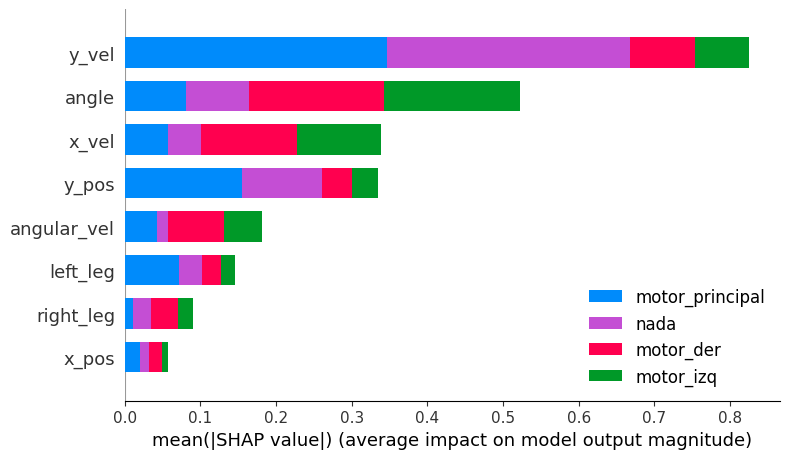

In [11]:
shap.summary_plot(
    shap_values,                 # la lista/array con las 4 clases
    X_test[:50],
    feature_names=FEATURE_NAMES,
    class_names=ACTION_NAMES,    # etiquetas de las 4 acciones
    plot_type="bar",
)


=== Acción 0: nada ===


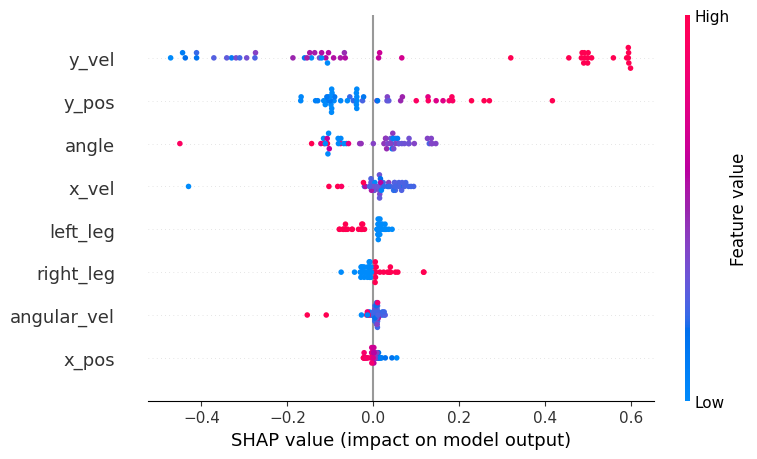


=== Acción 1: motor_izq ===


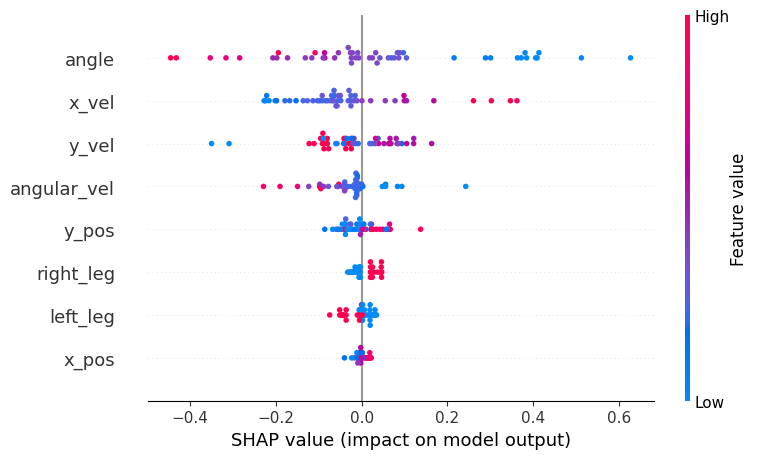


=== Acción 2: motor_principal ===


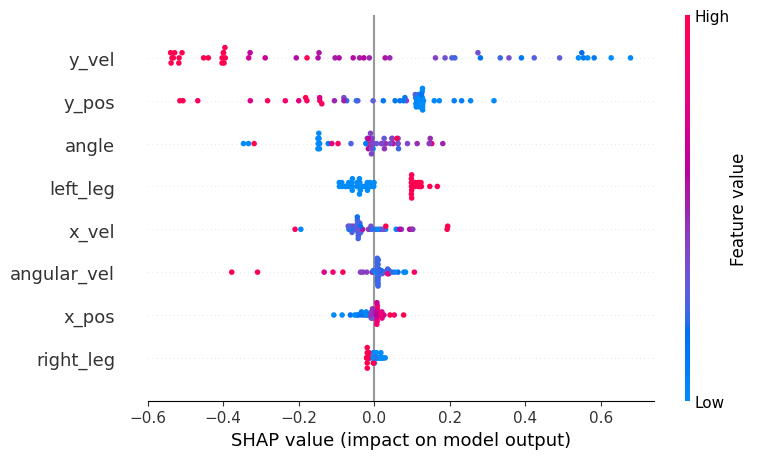


=== Acción 3: motor_der ===


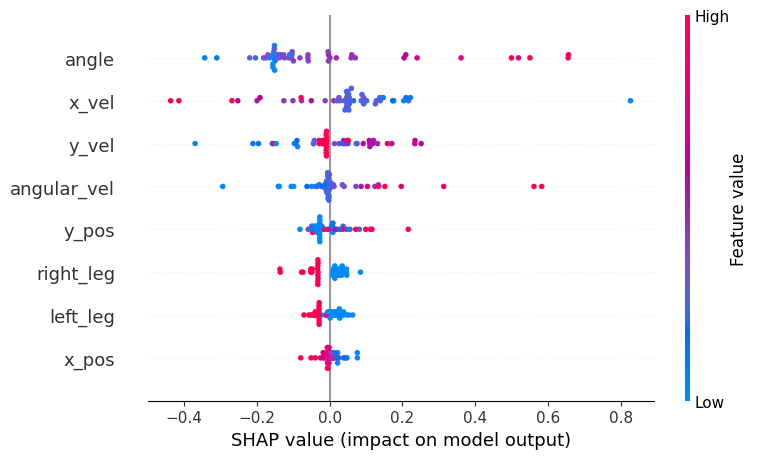

In [12]:
sv = shap_values
if isinstance(sv, np.ndarray) and sv.ndim == 3:
    sv = [sv[:, :, i] for i in range(sv.shape[2])]

for i, nombre in enumerate(ACTION_NAMES):
    print(f"\n=== Acción {i}: {nombre} ===")
    shap.summary_plot(sv[i],X_test[:50],feature_names=FEATURE_NAMES,show=True)

In [13]:
# max_depth controla el trade-off entre fidelidad e interpretabilidad
tree = DecisionTreeClassifier(max_depth=6, random_state=42)
tree.fit(X_train, y_train)

print(f"Fidelidad (accuracy vs A2C): {accuracy_score(y_test, tree.predict(X_test)):.3f}")
print(classification_report(y_test, tree.predict(X_test), target_names=ACTION_NAMES))

Fidelidad (accuracy vs A2C): 0.725
                 precision    recall  f1-score   support

           nada       0.92      0.91      0.92      3171
      motor_izq       0.70      0.37      0.48      2434
motor_principal       0.65      0.94      0.77      5129
      motor_der       0.72      0.39      0.51      2560

       accuracy                           0.72     13294
      macro avg       0.75      0.65      0.67     13294
   weighted avg       0.74      0.72      0.70     13294



In [14]:
for d in [3, 4, 5, 6, 8, 10, 15, 20]:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    print(f"depth={d:2d}  fidelidad={accuracy_score(y_test, t.predict(X_test)):.3f}")

depth= 3  fidelidad=0.664
depth= 4  fidelidad=0.701
depth= 5  fidelidad=0.710
depth= 6  fidelidad=0.725
depth= 8  fidelidad=0.750
depth=10  fidelidad=0.774
depth=15  fidelidad=0.817
depth=20  fidelidad=0.826


|--- y_vel <= -0.14
|   |--- y_vel <= -0.18
|   |   |--- y_pos <= 1.35
|   |   |   |--- angle <= 0.08
|   |   |   |   |--- angular_vel <= -0.05
|   |   |   |   |   |--- angle <= -0.12
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- angle >  -0.12
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |--- angular_vel >  -0.05
|   |   |   |   |   |--- y_pos <= 0.21
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |--- y_pos >  0.21
|   |   |   |   |   |   |--- class: 2
|   |   |   |--- angle >  0.08
|   |   |   |   |--- y_vel <= -0.29
|   |   |   |   |   |--- angle <= 0.32
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |--- angle >  0.32
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |--- y_vel >  -0.29
|   |   |   |   |   |--- angular_vel <= 0.49
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |--- angular_vel >  0.49
|   |   |   |   |   |   |--- class: 3
|   |   |--- y_pos >  1.35
|   |   |   |--- x_vel <= -0.02
|   |   |   |   |--- y

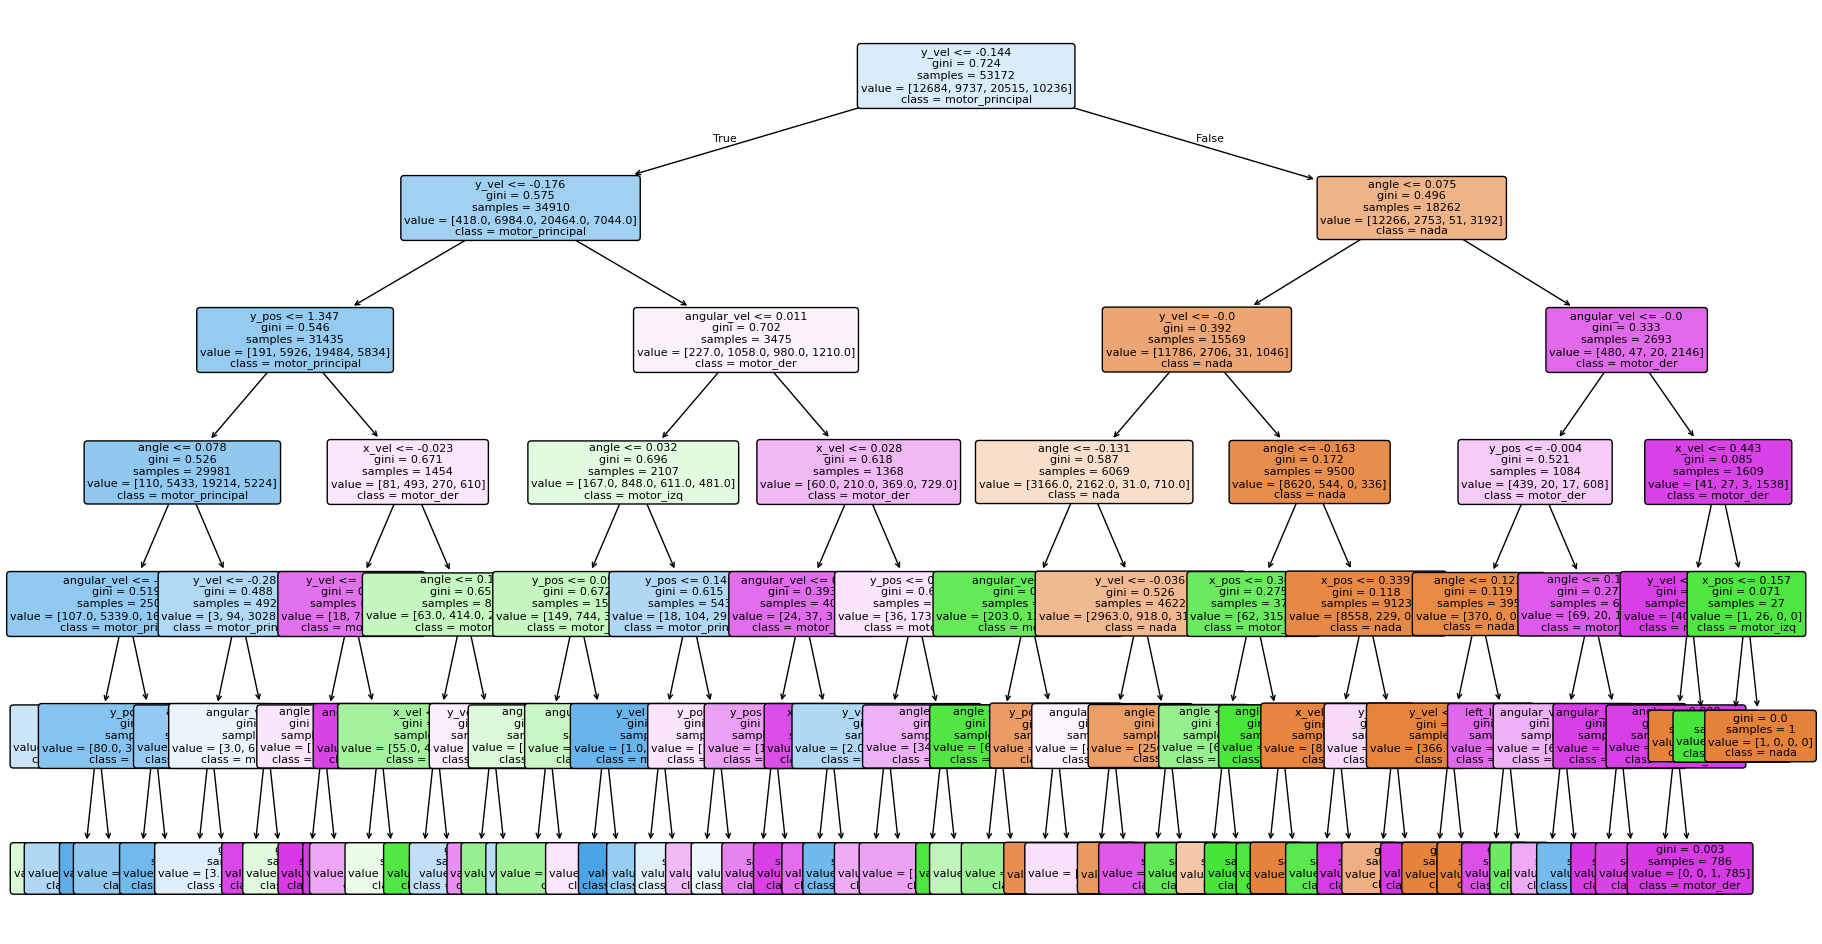

In [15]:
print(export_text(tree, feature_names=FEATURE_NAMES))

# Árbol gráfico
import matplotlib.pyplot as plt
plt.figure(figsize=(22, 12))
plot_tree(tree, feature_names=FEATURE_NAMES, class_names=ACTION_NAMES,filled=True, rounded=True, fontsize=8, max_depth=6)  # max_depth aquí solo recorta el dibujo
plt.savefig("arbol_lunarlander.png", dpi=150, bbox_inches="tight")

In [16]:
def evaluar_politica_arbol(tree, n_episodes=20):
    env = gym.make("LunarLander-v3")
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action = int(tree.predict(obs.reshape(1, -1))[0])
            obs, r, term, trunc, _ = env.step(action)
            total += r
            done = term or trunc
        rewards.append(total)
    env.close()
    return np.mean(rewards), np.std(rewards)

m, s = evaluar_politica_arbol(tree)
print(f"Recompensa del árbol: {m:.1f} ± {s:.1f}")

Recompensa del árbol: -7.1 ± 269.1


In [17]:
imp = pd.Series(tree.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
print(imp)

y_vel          0.607180
angle          0.229414
y_pos          0.058344
angular_vel    0.058073
x_vel          0.031879
x_pos          0.014956
left_leg       0.000154
right_leg      0.000000
dtype: float64
